# **Email-Spam Classification**

---

## **Table of Contents**

- [Environment Setup (Local or Google Colab)](#environment-setup-local-or-google-colab)
- [Introduction](#introduction)
- [Datasets Preparation](#datasets-preparation)
  - [Dataset Subsampling & Sequence Length Handling](#dataset-subsampling--sequence-length-handling)
  - [Download and Split Datasets](#download-and-split-datasets)
  - [Handling Long Context Sequences](#handling-long-context-sequences)
  - [Create Data Loaders](#create-data-loaders)
- [Model Setup](#model-setup)
  - [Initialize a Local GPT-2 Model and Load Weights From OpenAI](#initialize-a-local-gpt-2-model-and-load-weights-from-openai)
  - [Verify The Loaded Model](#verify-the-loaded-model)
  - [Classification Head Adaptation & Fine-Tuning Strategy](#classification-head-adaptation--fine-tuning-strategy)
  - [Sanity Check: Output Shape & Logit Verification](#sanity-check-output-shape--logit-verification)
- [Finetuning The Model](#finetuning-the-model)
  - [Pre-Fine-Tuning Baseline Evaluation](#pre-fine-tuning-baseline-evaluation)
  - [Fine-Tuning Execution & Optimizer Setup](#fine-tuning-execution--optimizer-setup)
  - [Visualization of Training Dynamics](#visualization-of-training-dynamics)
- [Final Metric Evaluation Across Datasets](#final-metric-evaluation-across-datasets)
  - [Performance Analysis & Observations](#performance-analysis--observations)


---

## **Environment Setup (Local or Google Colab)**

The code block below automatically detects your execution runtime environment (Local vs. Google Colab), clones the repository, and installs all necessary dependencies.

> **Google Colab Note:** Once setup completes, navigate to **Runtime → Restart session** in the top menu before proceeding to the next steps to ensure all newly installed packages are correctly loaded.

In [1]:
import os
import subprocess
import sys

import torch

# Environment Detection: Check sys.modules for Colab runtime
IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    print("Detected Google Colab environment. Initializing setup...")

    # Define paths
    branch = "dev"
    repo_url = (
        "https://github.com/paymantohidifar/gpt2-text-classifier-from-scratch.git"
    )
    target_dir = "/content/gpt2-classifier"

    # Clean stale builds and clone main branch
    subprocess.run(f"rm -rf {target_dir}", shell=True, check=True)
    subprocess.run(
        f"git clone {repo_url} --branch {branch} {target_dir}",
        shell=True,
        check=True,
    )
    print("Cloned the repo.")

    # Change working directory
    os.chdir(target_dir)

    # Bootstrap uv and install dependencies into system environment
    install_cmd = (
        'curl -LsSf https://astral.sh/uv/install.sh | sh && '
        'export PATH="$HOME/.local/bin:${PATH}" && '
        'uv pip install -e .[gpu,dev] --system --break-system-packages --color never'
    )
    print("Installing dependencies...")
    subprocess.run(install_cmd, shell=True, check=True)
    print("Colab setup complete.")

else:
    # Local Development: Enable IPython Auto-Reload safely
    ipython = get_ipython()
    if ipython is not None:
        ipython.run_line_magic("load_ext", "autoreload")
        ipython.run_line_magic("autoreload", "2")
        print("Enabled IPython autoreload.")


# Verify PyTorch version and config
print(f"\nInstalled Pytorch version: {torch.__version__}")
print(f"PyTorch enabled with Cuda: {torch.cuda.is_available()}")

Detected Google Colab environment. Initializing setup...
Cloned the repo.
Installing dependencies...
Colab setup complete.

Installed Pytorch version: 2.11.0+cu128
PyTorch enabled with Cuda: True


---

## **Introduction**

In this notebook, we fine-tune a custom GPT-2 binary text classifier (built from scratch) to categorize Emails as either **ham** or **spam** using the open-source **[Email Spam Collection](https://raw.githubusercontent.com/MWiechmann/enron_spam_data/master/enron_spam_data.zip)** dataset.

All underlying module classes and utility functions are imported from my custom `gpt2_classifier` package. Alternatively, you can execute end-to-end fine-tuning and inference via my command-line interface (CLI). For CLI flags and configuration options, please refer to the [README.md](../README.md).

---

## **Datasets Preparation**

The raw **Enron Spam** dataset has balanced class labels (~50% spam vs. ~50% ham). In this section, we download and construct training, validation, and test sets with a consistent 70%/10%/20% split using the `prepare_dataset` function.

### **Dataset Subsampling & Sequence Length Handling**

The **Enron Email Spam** dataset is substantially larger than the SMS Spam collection (33,716 samples). To accommodate hardware memory constraints and accelerate training iterations, we apply a 10% random subsampling factor via the `hold_frac` configuration parameter in the `prepare_dataset` function.

> **Trade-off Note:** Subsampling significantly reduces compute overhead, but shrinks overall dataset coverage, which may increase the risk of model overfitting.

### **Download and Split Datasets**

In [2]:
from gpt2_classifier.data import prepare_dataset
from gpt2_classifier.datasets_registry import get_dataset_spec

spec = get_dataset_spec("email-spam")
print(spec)

path = prepare_dataset(spec, hold_frac=0.1, force=True, balance_labels=False, dataset_split=(0.7, 0.1, 0.2))
print("File path:", path)

DatasetSpec(name='email-spam', url='https://raw.githubusercontent.com/MWiechmann/enron_spam_data/master/enron_spam_data.zip', raw_filename='enron_spam_data.csv', text_column='Message', label_column='Spam/Ham', label_map={'ham': 0, 'spam': 1}, archive_format='zip', separator=',', has_header=True, column_names=None, backup_url=None)
File downloaded and saved as /content/gpt2-classifier/data/email-spam/enron_spam_data.csv
File path: /content/gpt2-classifier/data/email-spam


### **Handling Long Context Sequences**

Email sequences are substantially longer than SMS messages (averaging 30,000–50,000 tokens per email vs. ~120 tokens for SMS). This drastically exceeds GPT-2's native context window limit of **1,024 tokens**.

While advanced strategies exist, such as **Rotary Position Embeddings (RoPE) scaling** or **sliding-window chunking** (splitting single long emails into $K$ overlapping batches), they fall outside the scope of this notebook.

For simplicity and execution speed, we will cap the context size to model's maximum context window size of 1024 directly within our `create_data_loaders` pipeline to truncate sequences. In the evaluation phase, we will analyze how this context truncation impacts model performance metrics.

### **Create Data Loaders**

We construct data loaders for the train, validation, and test splits to manage mini-batching during optimization. By default, we set `batch_size = 8` and enable shuffling on the training set to ensure mini-batches provide unbiased gradient estimates and prevent catastrophic order-dependent learning. As discussed above, we also set the context size `max_length=1024`.

*Note: While batch size is a tunable hyperparameter, scaling it up increases per-step memory consumption and may trigger Out-Of-Memory (OOM) errors depending on your GPU's VRAM capacity.*

In [3]:
from gpt2_classifier.data import create_data_loaders

train_loader, val_loader, test_loader = create_data_loaders(spec.name, max_length=1024, batch_size=8)

for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

Input batch dimensions: torch.Size([8, 1024])
Label batch dimensions torch.Size([8])
293 training batches
42 validation batches
84 test batches


---

## **Model Setup**

With our data loaders fully configured, we instantiate our custom GPT-2 architecture. Training a transformer language model from scratch requires millions of GPU hours to converge on meaningful semantic representations. To bypass this compute barrier, we populate our model’s parameters directly with OpenAI’s pretrained weights, retrieved using Hugging Face's safetensors API. This process is managed by two core utilities: `download_and_load_gpt2` (weight retrieval) and `load_weights_into_gpt` (state dict mapping).

For this notebook, we instantiate the base GPT-2 Small (124M parameters) model, which provides a strong capacity-to-compute ratio for our target dataset. You can experiment with larger variants by updating the `model_name` configuration string:

* `gpt2-small (124M)`
* `gpt2-medium (355M)`
* `gpt2-large (774M)`
* `gpt2-xl (1558M)`

*Note: Scaling up model size increases activation and optimizer memory footprints exponentially, requiring longer per-step latency and higher VRAM capacity.*

### **Initialize a Local GPT-2 Model and Load Weights From OpenAI**

In [4]:
from gpt2_classifier import paths
from gpt2_classifier.config import URL_DIR, get_model_config
from gpt2_classifier.model import GPTModel
from gpt2_classifier.weights import download_and_load_gpt2, load_weights_into_gpt

model_name = "gpt2-small (124M)"
model_config = get_model_config(model_name)
model_url = f"https://huggingface.co/openai-community/{URL_DIR[model_name]}/resolve/main/model.safetensors"
model_destination = paths.MODELS_DIR / f"{URL_DIR[model_name]}.safetensors"

state_dict = download_and_load_gpt2(model_url, model_destination)
model = GPTModel(model_config)
load_weights_into_gpt(model, state_dict)

print(model)

model.safetensors: 100%|██████████| 548M/548M [00:08<00:00, 61.7MiB/s]


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

### **Verify The Loaded Model**

To verify that the pretrained weight transfer succeeded and that our model state is correctly configured, we perform a qualitative sanity check by generating text from a prompt. Coherent text output confirms proper weight mapping across transformer layers, whereas unconditioned noise or gibberish indicates a state dict misalignment or missing layer keys.

In [5]:
from gpt2_classifier.utils import generate_response

text_1 = "Every effort moves you"

reponse = generate_response(
    text=text_1,
    model=model,
    max_new_tokens=15
)

print(reponse)

Every effort moves you forward.

The first step is to understand the importance of your work


### **Classification Head Adaptation & Fine-Tuning Strategy**

The standard GPT-2 language modeling head projects transformer hidden states to a vocabulary dimension of 50,257 logits. For our binary classification task, we replace this final projection layer with a linear head mapping the output dimension from $d_{\text{model}}$ to 2 class logits.

To minimize compute overhead and prevent catastrophic forgetting of pretrained representations, we freeze the majority of the transformer backbone. We restrict parameter updates exclusively to the final transformer block, the terminal LayerNorm layer, and the newly initialized classification head.

In [6]:
import torch

# Turn off all trainable parameters
for param in model.parameters():
    param.requires_grad = False

# Swap teh GPT-2 head with a binary head
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(in_features=model_config['emb_dim'], out_features=num_classes)

# Turn on last layer of transformer block
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

# Turn on final LayerNorm
for param in model.final_norm.parameters():
    param.requires_grad = True

print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

### **Sanity Check: Output Shape & Logit Verification**

We perform a quick forward pass using a toy data to verify that our modified architecture correctly outputs a tensor of shape `(batch_size, 2)`. Confirming that the classification head returns two unnormalized logits ensures that our state dict modifications and layer swaps align with the binary classification loss formulation prior to starting fine-tuning.

In [7]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print(inputs)

device = "cpu"
inputs = inputs.to(device)

with torch.no_grad():
    outputs = model(inputs)
print(outputs)
print(outputs.shape)

tensor([[5211,  345,  423,  640]])
tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
torch.Size([1, 4, 2])


---

## **Finetuning The Model**


### **Pre-Fine-Tuning Baseline Evaluation**

Before initiating parameter updates, we evaluate our initialized model across the training, validation, and test splits to establish benchmark loss and accuracy metrics. Recording pre-training baselines serves two critical functions: it quantifies the exact performance gains attributable to fine-tuning and acts as a diagnostic check to ensure loss decreases monotonically from a reasonable starting point.

In [8]:
from gpt2_classifier.evaluate import calc_accuracy_loader, calc_loss_loader
from gpt2_classifier.utils import get_device

device = get_device()
model.to(device)

torch.manual_seed(123)

# Compute accuracy for all three datasets
train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")


# Compute losses for all three datasets
with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training accuracy: 40.00%
Validation accuracy: 55.00%
Test accuracy: 56.25%
Training loss: 4.247
Validation loss: 3.699
Test loss: 3.579


### **Fine-Tuning Execution & Optimizer Setup**

With baseline benchmarks established, we can now proceed to fine-tune our classifier. Before launching the training loop, we must instantiate our optimization algorithm. We utilize the AdamW optimizer for model training. For a concise breakdown of Adam versus AdamW (specifically regarding decoupled weight decay), please refer to the [01_sms_spam_classification](https://colab.research.google.com/github/paymantohidifar/gpt2-text-classifier-from-scratch/blob/main/notebooks/01_sms_spam_classification.ipynb) notebook.

Due to the expanded sequence context window and the larger volume of training examples, fine-tuning will take significantly longer, approximately 5 minutes per epoch on an Nvidia T4 GPU via Google Colab.

In [9]:
import time

from gpt2_classifier.train import get_adam_param_groups, train_classifier_simple
from gpt2_classifier.utils import get_device

device = get_device()
model.to(device)

start_time = time.time()

torch.manual_seed(123)
# optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
optim_groups = get_adam_param_groups(model, weight_decay=0.1)
optimizer = torch.optim.AdamW(optim_groups, lr=5e-5)

num_epochs = 5

history = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=100, eval_iter=10,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 4.306, Val loss 3.614
Ep 1 (Step 000100): Train loss 0.944, Val loss 0.872
Ep 1 (Step 000200): Train loss 0.877, Val loss 0.816
Training accuracy: 53.75% | Validation accuracy: 48.75%
Train precision: 0.483, ROC-AUC: 0.551, PR-AUC: 0.477 | Val precision: 0.533, ROC-AUC: 0.580, PR-AUC: 0.571
Ep 2 (Step 000300): Train loss 0.715, Val loss 0.714
Ep 2 (Step 000400): Train loss 0.636, Val loss 0.650
Ep 2 (Step 000500): Train loss 0.729, Val loss 0.634
Training accuracy: 58.75% | Validation accuracy: 63.75%
Train precision: 0.561, ROC-AUC: 0.653, PR-AUC: 0.651 | Val precision: 0.603, ROC-AUC: 0.720, PR-AUC: 0.763
Ep 3 (Step 000600): Train loss 0.678, Val loss 0.627
Ep 3 (Step 000700): Train loss 0.725, Val loss 0.611
Ep 3 (Step 000800): Train loss 0.639, Val loss 0.632
Training accuracy: 52.50% | Validation accuracy: 66.25%
Train precision: 0.529, ROC-AUC: 0.585, PR-AUC: 0.621 | Val precision: 0.682, ROC-AUC: 0.728, PR-AUC: 0.768
Ep 4 (Step 000900): Train loss 

We could also use `finetune_model` function to automatically set up the optimizer, train the model, and checkpoint the trained model.

### **Visualization of Training Dynamics**

Below, we plot the trajectory of our primary training and validation metrics across epochs.

*Note: While our CLI script supports the `--use-wandb` flag for real-time cloud tracking of loss curves, evaluation metrics, and hardware utilization (GPU/VRAM throughput), we use static inline visualizations here for standalone notebook execution.*

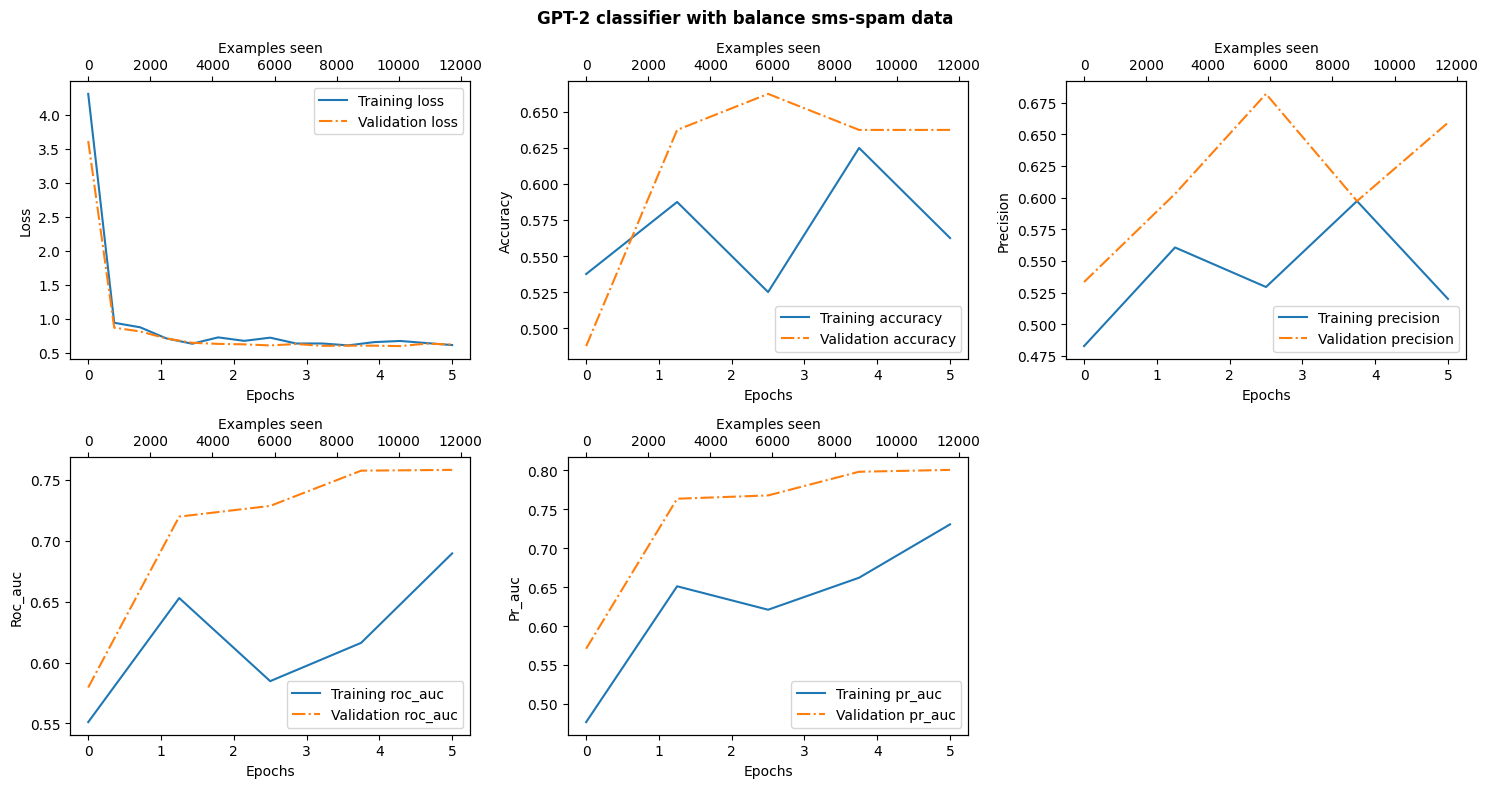

/content/gpt2-classifier/plots/email-spam/metrics.png


In [10]:
from gpt2_classifier.utils import plot_results

fig_path = plot_results(
    num_epochs, *history,
    dataset="email-spam",
    title="GPT-2 classifier with balance sms-spam data"
    )

print(fig_path)

---

## **Final Metric Evaluation Across Datasets**

As a final step in our evaluation pipeline, we compute comprehensive classification metrics across the training, validation, and test splits. Aggregating performance over all dataset mini-batches provides a statistically robust, out-of-sample assessment of our fine-tuned model's generalization capability.

In [11]:
from gpt2_classifier.evaluate import calc_classification_metrics_loader

train_metrics = calc_classification_metrics_loader(train_loader, model, device, num_batches=300)
val_metrics = calc_classification_metrics_loader(val_loader, model, device, num_batches=300)
test_metrics = calc_classification_metrics_loader(test_loader, model, device, num_batches=300)

print("Training metrics:")
print(
    f"Accuracy: {train_metrics.accuracy:.3f} | Precision: {train_metrics.precision:.3f} | ROC-AUC: {train_metrics.roc_auc:.3f}, |"
    f"PR-AUC: {train_metrics.pr_auc:.3f}\n"
)

print("Validation metrics:")
print(
    f"Accuracy: {val_metrics.accuracy:.3f} | Precision: {val_metrics.precision:.3f} | ROC-AUC: {val_metrics.roc_auc:.3f}, |"
    f"PR-AUC: {val_metrics.pr_auc:.3f}\n"
)

print("Test metrics:")
print(
    f"Accuracy: {test_metrics.accuracy:.3f} | Precision: {test_metrics.precision:.3f} | ROC-AUC: {test_metrics.roc_auc:.3f}, |"
    f"PR-AUC: {test_metrics.pr_auc:.3f}\n"
)

Training metrics:
Accuracy: 0.642 | Precision: 0.621 | ROC-AUC: 0.717, |PR-AUC: 0.752

Validation metrics:
Accuracy: 0.644 | Precision: 0.626 | ROC-AUC: 0.737, |PR-AUC: 0.762

Test metrics:
Accuracy: 0.640 | Precision: 0.615 | ROC-AUC: 0.697, |PR-AUC: 0.706



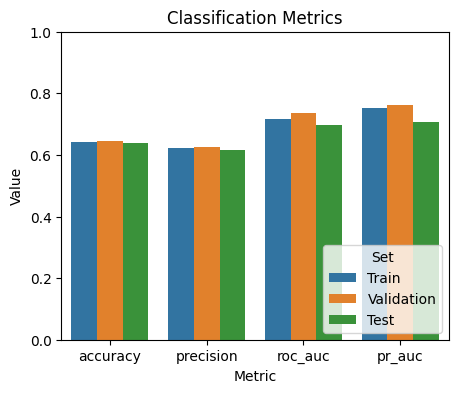

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Combine all metrics for Train, Validation, and Test sets in one dataframe
metrics_df = pd.DataFrame(
    {
        'Train': dict(train_metrics),
        'Validation': dict(val_metrics),
        'Test': dict(test_metrics),
    },
    index=pd.Index(['accuracy', 'precision', 'roc_auc', 'pr_auc'], name='Metric')
).reset_index()

# Pivot dataframe suitable for plotting
metrics_df_long = pd.melt(
    metrics_df, id_vars=['Metric'], value_vars=['Train', 'Validation', 'Test'], var_name='Set', value_name='Value')

fig, ax = plt.subplots(figsize=(5,4))

sns.barplot(ax=ax, data=metrics_df_long, x='Metric', y='Value', hue='Set')
ax.set_title("Classification Metrics")
ax.set_xlabel("Metric")
ax.set_ylabel("Value")
ax.set_ylim(0, 1.0)
ax.legend(title="Set", loc="lower right")
plt.show()
fig_dir  = paths.PLOTS_DIR / spec.name
if not fig_dir.exists():
    fig_dir.mkdir(parents=True)
fig.savefig(fig_dir / "model_metrics.png", dpi=300, bbox_inches='tight');

### **Performance Analysis & Observations**

Across this training run, we observe consistent improvements across all metrics; however, overall performance remains below target expectations. Key observations include:

* **Overfitting**: There are currently no signs of overfitting at this epoch. Validation loss continues to closely track training loss.

* **Convergence Rate**: The model shows steady progress, suggesting that training for additional epochs could yield further gains. However, the loss profile indicates that convergence is slowing down and performance improvements will likely be gradual.

* **Primary Bottleneck**: A primary contributor to the lower-than-expected performance is context window truncation. Due to memory limits and max sequence length constraints, we are training on only a sub-fraction of the available text tokens per example, omitting valuable contextual signals.